##IMPORTACIONES Y CONFIGURACIÓN DE REPRODUCIBILIDAD

In [ ]:
# IMPORTACIONES Y CONFIGURACIÓN DE REPRODUCIBILIDAD
# =================================================

import numpy as np
import pandas as pd  # Make sure pandas is installed
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf  # Added explicit import for tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

import os

np.random.seed(1)
tf.random.set_seed(1)  # Now tf is properly defined



In [ ]:
from tensorflow.keras.datasets import cifar10

# ==================== CARGAR DATASET ====================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
from sklearn.model_selection import train_test_split

# ==================== EXPLORAR LOS DATOS ====================
print(f"Shape de x_train: {x_train.shape}")  # (50000, 32, 32, 3) - 50k imágenes 32x32 RGB
print(f"Shape de y_train: {y_train.shape}")  # (50000, 1) - 50k etiquetas
print(f"Shape de x_test: {x_test.shape}")    # (10000, 32, 32, 3) - 10k imágenes de prueba
print(f"Shape de y_test: {y_test.shape}")    # (10000, 1) - 10k etiquetas

print(f"\nRango de píxeles: {x_train.min()} a {x_train.max()}")  # 0 a 255
print(f"Número de clases: {len(np.unique(y_train))}")  # 10 clases (avión, carro, etc.)

# ==================== NORMALIZAR IMÁGENES ====================
# Convertir píxeles de [0, 255] a [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"\nDespués de normalizar: {x_train.min()} a {x_train.max()}")  # 0.0 a 1.0

# ==================== CREAR CONJUNTO DE VALIDACIÓN ====================
# Dividir train en train (80%) y validación (20%)
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,      # 20% para validación
    random_state=42,    # Semilla para reproducibilidad
    stratify=y_train    # Mantener proporción de clases
)

print("\n==================== CONJUNTOS FINALES ====================")
print(f"x_train: {x_train.shape}")  # (40000, 32, 32, 3)
print(f"y_train: {y_train.shape}")  # (40000, 1)
print(f"x_val:   {x_val.shape}")    # (10000, 32, 32, 3)
print(f"y_val:   {y_val.shape}")    # (10000, 1)
print(f"x_test:  {x_test.shape}")   # (10000, 32, 32, 3)
print(f"y_test:  {y_test.shape}")   # (10000, 1)

# ==================== CONVERTIR LABELS A ONE-HOT ENCODING ====================
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)  # 10 clases
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

print("\n==================== DESPUÉS DE ONE-HOT ====================")
print(f"y_train: {y_train.shape}")  # (40000, 10)
print(f"y_val:   {y_val.shape}")    # (10000, 10)
print(f"y_test:  {y_test.shape}")   # (10000, 10)




Shape de x_train: (50000, 32, 32, 3)
Shape de y_train: (50000, 1)
Shape de x_test: (10000, 32, 32, 3)
Shape de y_test: (10000, 1)

Rango de píxeles: 0 a 255
Número de clases: 10

Después de normalizar: 0.0 a 1.0

==================== CONJUNTOS FINALES ====================
x_train: (40000, 32, 32, 3)
y_train: (40000, 1)
x_val:   (10000, 32, 32, 3)
y_val:   (10000, 1)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 1)

==================== DESPUÉS DE ONE-HOT ====================
y_train: (40000, 10)
y_val:   (10000, 10)
y_test:  (10000, 10)


##EJEMPLOS IMÁGENES

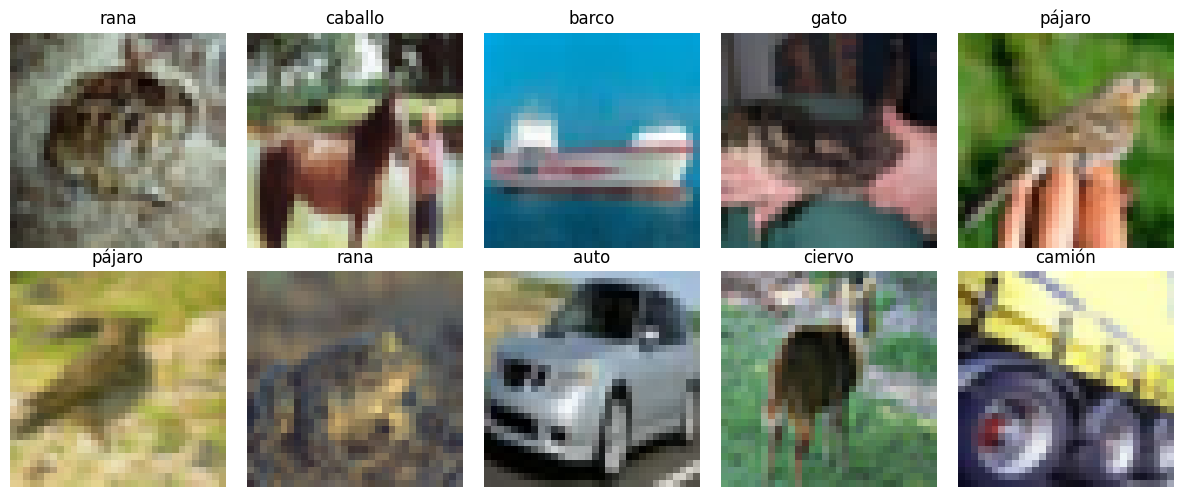

In [ ]:

# Nombres de las clases de CIFAR-10
class_names = ['avión', 'auto', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Mostrar 10 imágenes de ejemplo
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])

    # Encontrar el índice de la clase (deshacer one-hot)
    class_idx = np.argmax(y_train[i])
    plt.title(class_names[class_idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

##CONSTRUCCIÓN DEL MODELO CNN CON GLOBALAVERAGEPOOLING2D

In [ ]:
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.models import Model


# CONSTRUCCIÓN DEL MODELO CNN CON GLOBALAVERAGEPOOLING2D
# ======================================================

model = Sequential()                             # Crear modelo secuencial

model.add(Input(shape=(32, 32, 3)))              # Capa entrada: forma de las imágenes (28×28×1)

model.add(Conv2D(32, (3, 3), activation='relu')) # 1ra capa conv.: 32 filtros, kernel de 3×3, ReLU
model.add(MaxPooling2D((2, 2)))                  # 1ra capa pooling: MaxPooling con poolsize de 2×2
model.add(Dropout(0.25))                         # Dropout del 25%

model.add(Conv2D(64, (3, 3), activation='relu')) # 2da capa conv.: 64 filtros, kernel de 3×3, ReLU
model.add(MaxPooling2D((2, 2)))                  # 2da capa pooling: MaxPooling con poolsize de 2×2
model.add(Dropout(0.25))                         # Dropout del 25%

model.add(Conv2D(128, (3, 3), activation='relu')) # 3ra capa conv.: 128 filtros, kernel de 3×3, ReLU
model.add(MaxPooling2D((2, 2)))                  # 3ra capa pooling: MaxPooling con poolsize de 2×2
model.add(Dropout(0.25))                         # Dropout del 25%

model.add(GlobalAveragePooling2D())              # GlobalAveragePooling2D: promedio de c/ feature map
                                                 # backbone fuerte, head liviana!
model.add(Dense(256, activation='relu'))         # 1ra capa oculta: 256 neuronas, ReLU
model.add(Dropout(0.45))                         # Dropout del 45%

model.add(Dense(10, activation='softmax'))       # Capa salida: 10 neuronas (dígito 0-9), Softmax

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,842 (503.29 KB)

 Trainable params: 128,842 (503.29 KB)

 Non-trainable params: 0 (0.00 B)

##COMPILACIÓN Y ENTRENAMIENTO

In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=16,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=200,
    verbose=1,
    validation_data=(x_val, y_val),
    callbacks=[early_stop])

Epoch 1/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2142 - loss: 2.0402 - val_accuracy: 0.4103 - val_loss: 1.6009
Epoch 2/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4187 - loss: 1.5692 - val_accuracy: 0.5179 - val_loss: 1.3432
Epoch 3/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4908 - loss: 1.3939 - val_accuracy: 0.5637 - val_loss: 1.2203
Epoch 4/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5269 - loss: 1.3057 - val_accuracy: 0.5773 - val_loss: 1.1799
Epoch 5/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5703 - loss: 1.2172 - val_accuracy: 0.5928 - val_loss: 1.1492
Epoch 6/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5849 - loss: 1.1649 - val_accuracy: 0.6079 - val_loss: 1.1108
Epoch 7/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6043 - loss: 1.1239 - val_accuracy: 0.6241 - val_loss: 1.0524
Epoch 8/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6156 - loss: 1.0901 - val_acc

##PREDICCIONES

In [ ]:
# Realizar predicciones
y_pred = model.predict(x_test)

# Convertir one-hot encoding a índices de clase
y_test_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Classification Report
report = classification_report(y_test_classes, y_pred_classes, target_names=class_names)
print(report)




313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

       avión       0.79      0.81      0.80      1000
        auto       0.91      0.88      0.89      1000
      pájaro       0.76      0.60      0.68      1000
        gato       0.61      0.58      0.60      1000
      ciervo       0.72      0.78      0.75      1000
       perro       0.71      0.68      0.70      1000
        rana       0.76      0.86      0.81      1000
     caballo       0.80      0.81      0.81      1000
       barco       0.81      0.92      0.86      1000
      camión       0.88      0.84      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.77     10000
weighted avg       0.78      0.78      0.77     10000



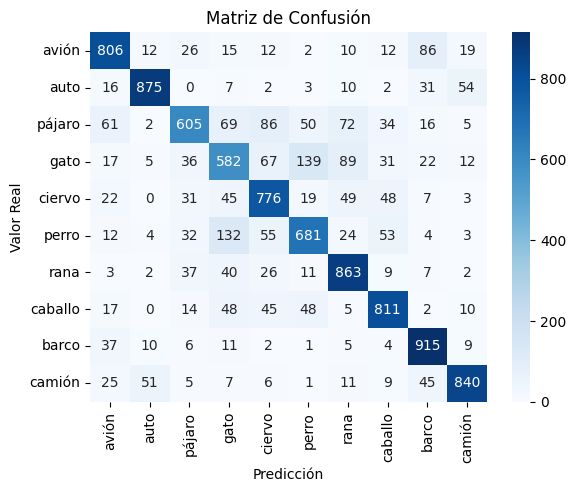

In [ ]:
# Visualizar matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()


##CURVAS DE APRENDIZAJE

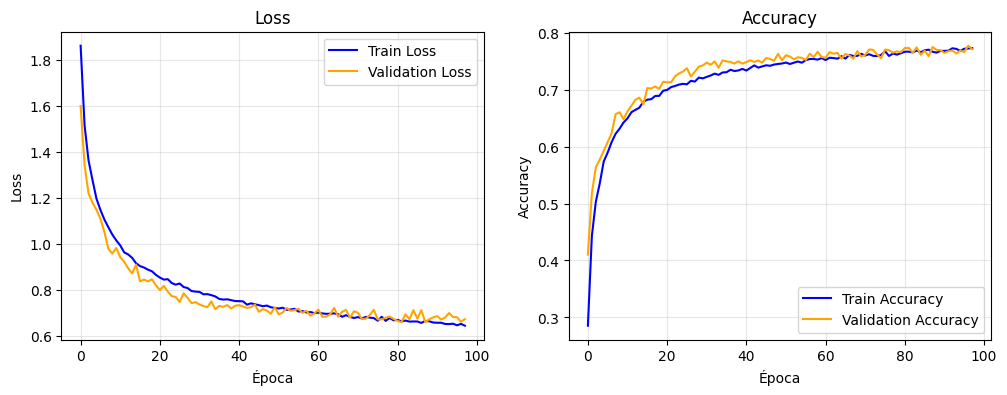

TRAIN:
Loss óptimo: 0.6633
Accuracy óptimo: 76.70%
Loss final: 0.6445
Accuracy final: 77.32%

VALIDATION:
Loss óptimo: 0.6598
Accuracy óptimo: 77.36%
Loss final: 0.6732
Accuracy final: 77.12%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# VISUALIZACIÓN DE CURVAS DESPUÉS DE FEATURE EXTRACTION
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gráfico de Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

plt.show()

# Mostrar valores de entrenamiento
best_epoch = np.argmin(history.history['val_loss'])
print(f"TRAIN:")
print(f"Loss óptimo: {history.history['loss'][best_epoch]:.4f}")
print(f"Accuracy óptimo: {history.history['accuracy'][best_epoch]*100:.2f}%")
print(f"Loss final: {history.history['loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['accuracy'][-1]*100:.2f}%")
print()
print(f"VALIDATION:")
print(f"Loss óptimo: {history.history['val_loss'][best_epoch]:.4f}")
print(f"Accuracy óptimo: {history.history['val_accuracy'][best_epoch]*100:.2f}%")
print(f"Loss final: {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['val_accuracy'][-1]*100:.2f}%")